
# 1D Kalman Filter

## Problem Setup
- True object moves in **1D**
- We receive **noisy position measurements**
- Goal: **estimate the true position over time** using a Kalman Filter



## Imports
We use:
- **NumPy** for numerical and matrix operations
- **Matplotlib** for visualization


In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Simulation Parameters
We simulate an object moving with **constant velocity** in 1D.

In [4]:
np.random.seed(42)  # for reproducibility
n_steps = 50        # number of time steps
true_velocity = 1  # constant velocity
dt = 1.0           # time step

## Generate True State and Noisy Measurements
- `true_positions` → ground truth (unknown in real life)
- `measurements` → noisy sensor readings

In [53]:
true_positions = []
measurements = []
position = 0.0
measurement_noise_std = 2.0  # sensor noise (R)
for _ in range(n_steps):
    position += true_velocity * dt
    true_positions.append(position)
    noisy_measurement = position + np.random.normal(0, measurement_noise_std)
    measurements.append(noisy_measurement)

## Kalman Filter Initialization
We initialize:
- State estimate
- Uncertainty
- Model matrices
- Noise values

In [62]:
# Initial state estimate (position only)
x_est = np.array([[100.0]])  # initial guess

# Initial uncertainty
P = np.array([[10.0]])     # large value = low confidence

# State transition matrix
F = np.array([[1.0]])

# Measurement matrix
H = np.array([[1.0]])

# Process noise (model uncertainty)
Q = np.array([[0.1]])

# Measurement noise (sensor uncertainty)
R = np.array([[measurement_noise_std ** 2]])

## Kalman Filter Loop
Each iteration performs:
1. Prediction
2. Update

In [63]:
estimates = []
k_gain = []
for z in measurements:
    # ------------------
    # PREDICTION STEP
    # ------------------
    x_pred = F @ x_est
    P_pred = F @ P @ F.T + Q

    # ------------------
    # UPDATE STEP
    # ------------------
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    k_gain.append(K.item())

    y = np.array([[z]]) - H @ x_pred   # innovation
    x_est = x_pred + K @ y

    P = (np.eye(1) - K @ H) @ P_pred

    estimates.append(x_est.item())

## Visualization
You should observe:
- Noisy measurements
- Smooth Kalman estimate
- Estimate closely following true position

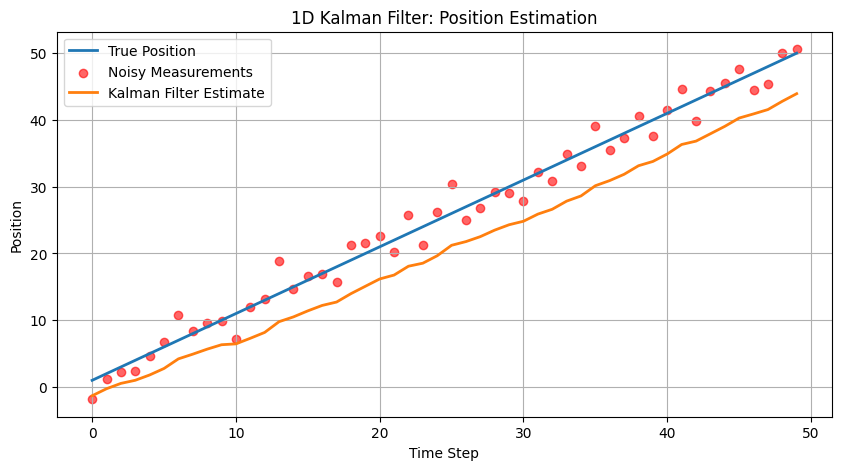

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(true_positions, label="True Position", linewidth=2)
plt.scatter(range(n_steps), measurements, label="Noisy Measurements", color="red", alpha=0.6)
plt.plot(estimates, label="Kalman Filter Estimate", linewidth=2)
plt.xlabel("Time Step")
plt.ylabel("Position")
plt.title("1D Kalman Filter: Position Estimation")
plt.legend()
plt.grid(True)
plt.show()

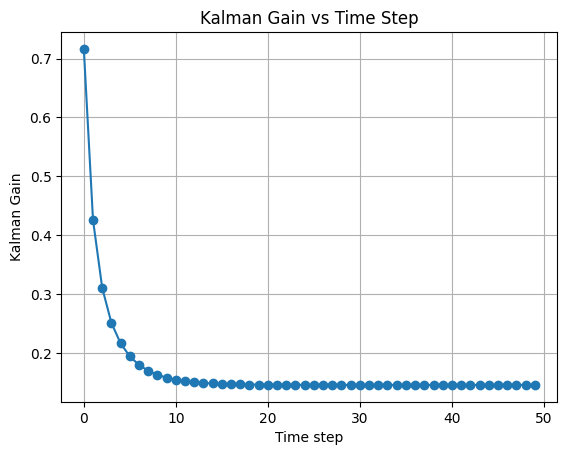

In [31]:
plt.figure()
plt.plot (k_gain, marker='o')
plt.xlabel("Time step")
plt.ylabel("Kalman Gain")
plt.title("Kalman Gain vs Time Step")
plt.grid(True)
plt.show()

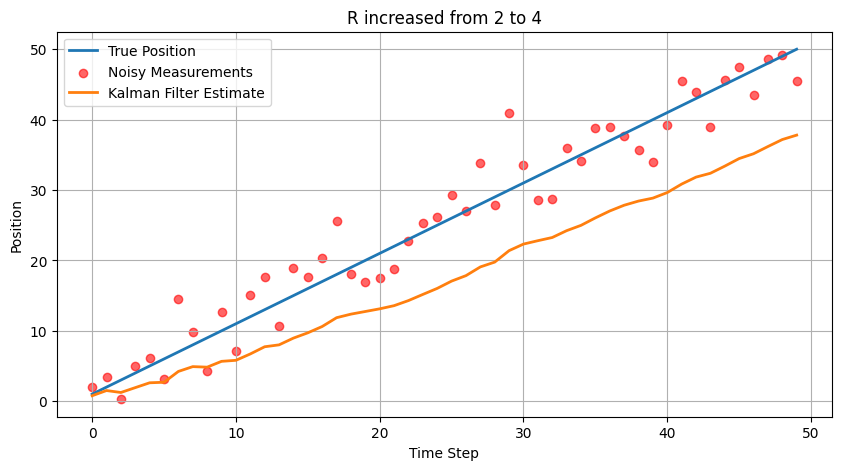

In [35]:
#measurement error(std) changed to 4
plt.figure(figsize=(10, 5))
plt.plot(true_positions, label="True Position", linewidth=2)
plt.scatter(range(n_steps), measurements, label="Noisy Measurements", color="red", alpha=0.6)
plt.plot(estimates, label="Kalman Filter Estimate", linewidth=2)
plt.xlabel("Time Step")
plt.ylabel("Position")
plt.title("R increased from 2 to 4")
plt.legend()
plt.grid(True)
plt.show()

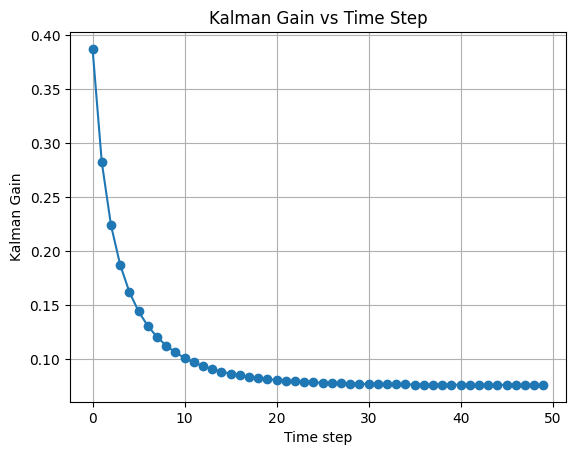

In [36]:
plt.figure()
plt.plot (k_gain, marker='o')
plt.xlabel("Time step")
plt.ylabel("Kalman Gain")
plt.title("Kalman Gain vs Time Step")
plt.grid(True)
plt.show()

As a direct consequence of increasing R, the deviation of measurements from the original value has increased. This leads to an increased mismatch in the kalmann estimate with the true value but we could see the system adapting its kalmann gain in such a way to reduce dependency on the measured values faster than the previous case.

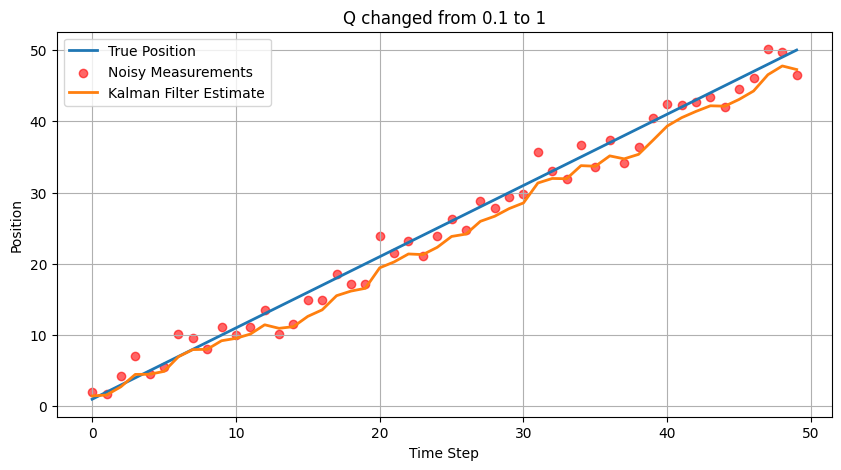

In [41]:
#process uncertaininty increased from 0.1 to 1
plt.figure(figsize=(10, 5))
plt.plot(true_positions, label="True Position", linewidth=2)
plt.scatter(range(n_steps), measurements, label="Noisy Measurements", color="red", alpha=0.6)
plt.plot(estimates, label="Kalman Filter Estimate", linewidth=2)
plt.xlabel("Time Step")
plt.ylabel("Position")
plt.title("Q changed from 0.1 to 1")
plt.legend()
plt.grid(True)
plt.show()

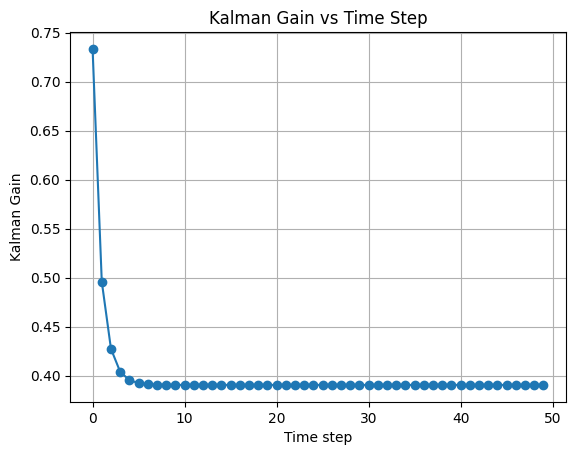

In [42]:
plt.figure()
plt.plot (k_gain, marker='o')
plt.xlabel("Time step")
plt.ylabel("Kalman Gain")
plt.title("Kalman Gain vs Time Step")
plt.grid(True)
plt.show()

With the increase in process uncertaininty the model estimate now follows the measured value closer than the base case. The model adapts itself to use the measured value with a higher weight as it settles the Kalmann gain at a higher value compared to the previous case.

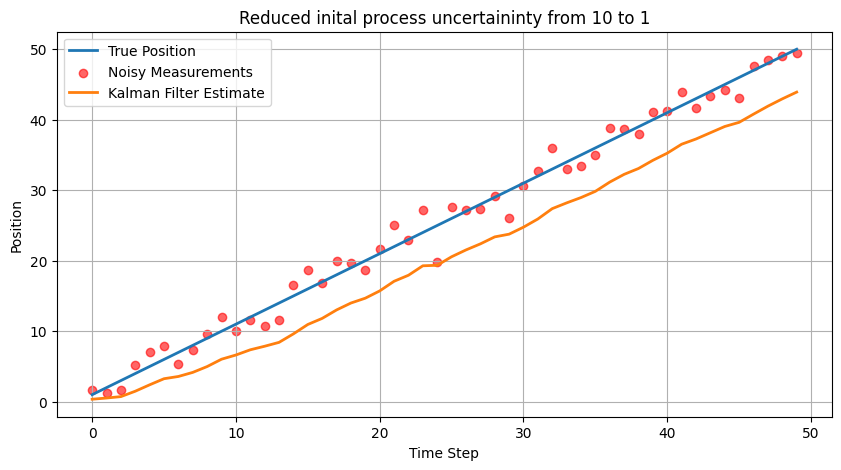

In [46]:
#initial uncertaininty decreased from 10 to 1
plt.figure(figsize=(10, 5))
plt.plot(true_positions, label="True Position", linewidth=2)
plt.scatter(range(n_steps), measurements, label="Noisy Measurements", color="red", alpha=0.6)
plt.plot(estimates, label="Kalman Filter Estimate", linewidth=2)
plt.xlabel("Time Step")
plt.ylabel("Position")
plt.title("Reduced inital process uncertaininty from 10 to 1")
plt.legend()
plt.grid(True)
plt.show()

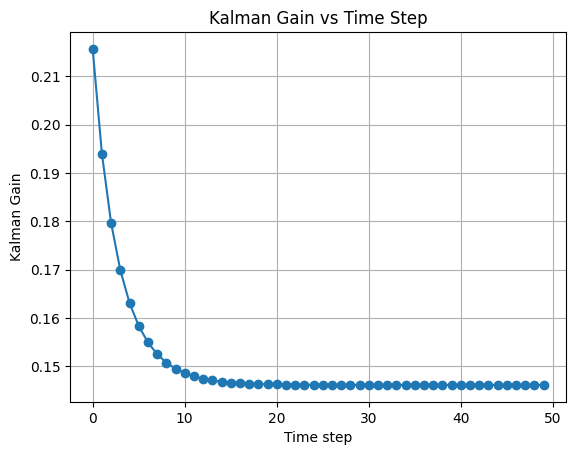

In [47]:
plt.figure()
plt.plot (k_gain, marker='o')
plt.xlabel("Time step")
plt.ylabel("Kalman Gain")
plt.title("Kalman Gain vs Time Step")
plt.grid(True)
plt.show()

The effect of reduction of initial uncertainity is not much evident on the long run performance of the system. However initially the model closely follows the predicted values but finally it is self correcting and settles at a similar kalmann gain as the base case indicating its self sustaining ability.  

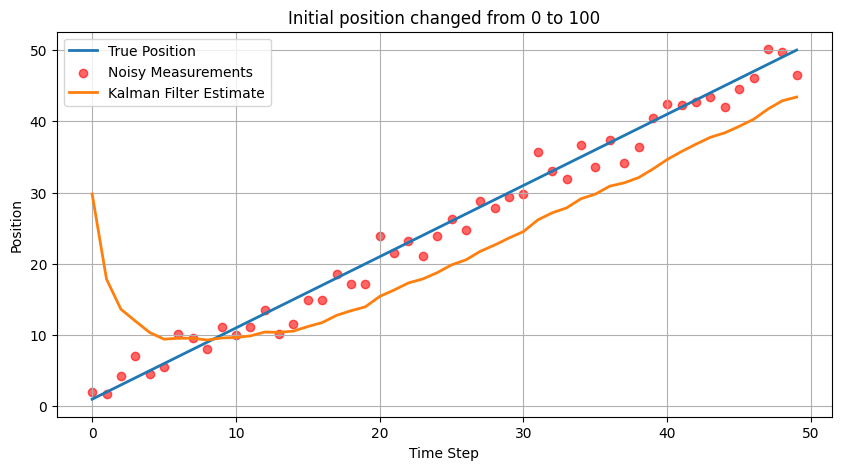

In [66]:
#initial state changed from 0 to 100
plt.figure(figsize=(10, 5))
plt.plot(true_positions, label="True Position", linewidth=2)
plt.scatter(range(n_steps), measurements, label="Noisy Measurements", color="red", alpha=0.6)
plt.plot(estimates, label="Kalman Filter Estimate", linewidth=2)
plt.xlabel("Time Step")
plt.ylabel("Position")
plt.title("Initial position changed from 0 to 100")
plt.legend()
plt.grid(True)
plt.show()

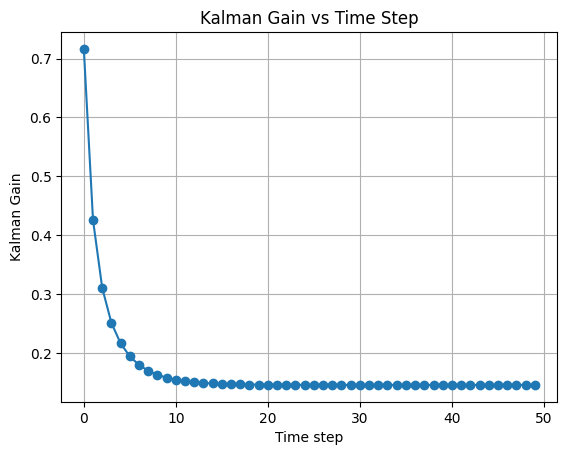

In [67]:
plt.figure()
plt.plot (k_gain, marker='o')
plt.xlabel("Time step")
plt.ylabel("Kalman Gain")
plt.title("Kalman Gain vs Time Step")
plt.grid(True)
plt.show()

Even if the initial measurement is off by a great value, the model is able to recover from it due to the large uncertaininty associated with the initial guess. This shows the robustness of the kalmann filter to navigate through an unknown initial state.

In [5]:
# estimation of position an velocity

true_positions = []
true_velocities = []
measurements = []
position = 0.0
velocity = 0.0
accelaration_std = 2.0
measurement_noise_std = 2.0  # sensor noise (R)
for _ in range(n_steps):
    a = np.random.normal(0,accelaration_std)
    position += velocity * dt + 0.5*a*dt*dt
    velocity += a*dt
    true_positions.append(position)
    true_velocities.append(velocity)
    noisy_measurement = position + np.random.normal(0, measurement_noise_std)
    measurements.append(noisy_measurement)

In [6]:
# Initial state estimate (position only)
x_est = np.array([[0],[0]])  # initial guess

# Initial uncertainty
P = np.array([[10.0,0],[0,10]])     # large value = low confidence

# State transition matrix
F = np.array([[1.0, dt], [0,1]])

# Measurement matrix
H = np.array([[1.0,0]])

# Process noise (model uncertainty)
Q = np.array([[np.pow(dt,4)/4 , np.pow(dt,3)/2], [np.pow(dt,3)/2 , np.pow(dt,2)]])*accelaration_std**2

# Measurement noise (sensor uncertainty)
R = np.array([[measurement_noise_std ** 2]])

In [7]:
estimates_x = []
estimates_v = []
k_gain_x = []
k_gain_v = []
for z in measurements:
    # ------------------
    # PREDICTION STEP
    # ------------------
    x_pred = F @ x_est
    P_pred = F @ P @ F.T + Q

    # ------------------
    # UPDATE STEP
    # ------------------
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    k_gain_x.append(K[0,0])
    k_gain_v.append(K[1,0])

    y = np.array([[z]]) - H @ x_pred   # innovation
    x_est = x_pred + K @ y

    P = (np.eye(2) - K @ H) @ P_pred

    estimates_x.append(x_est[0,0])
    estimates_v.append(x_est[1,0])

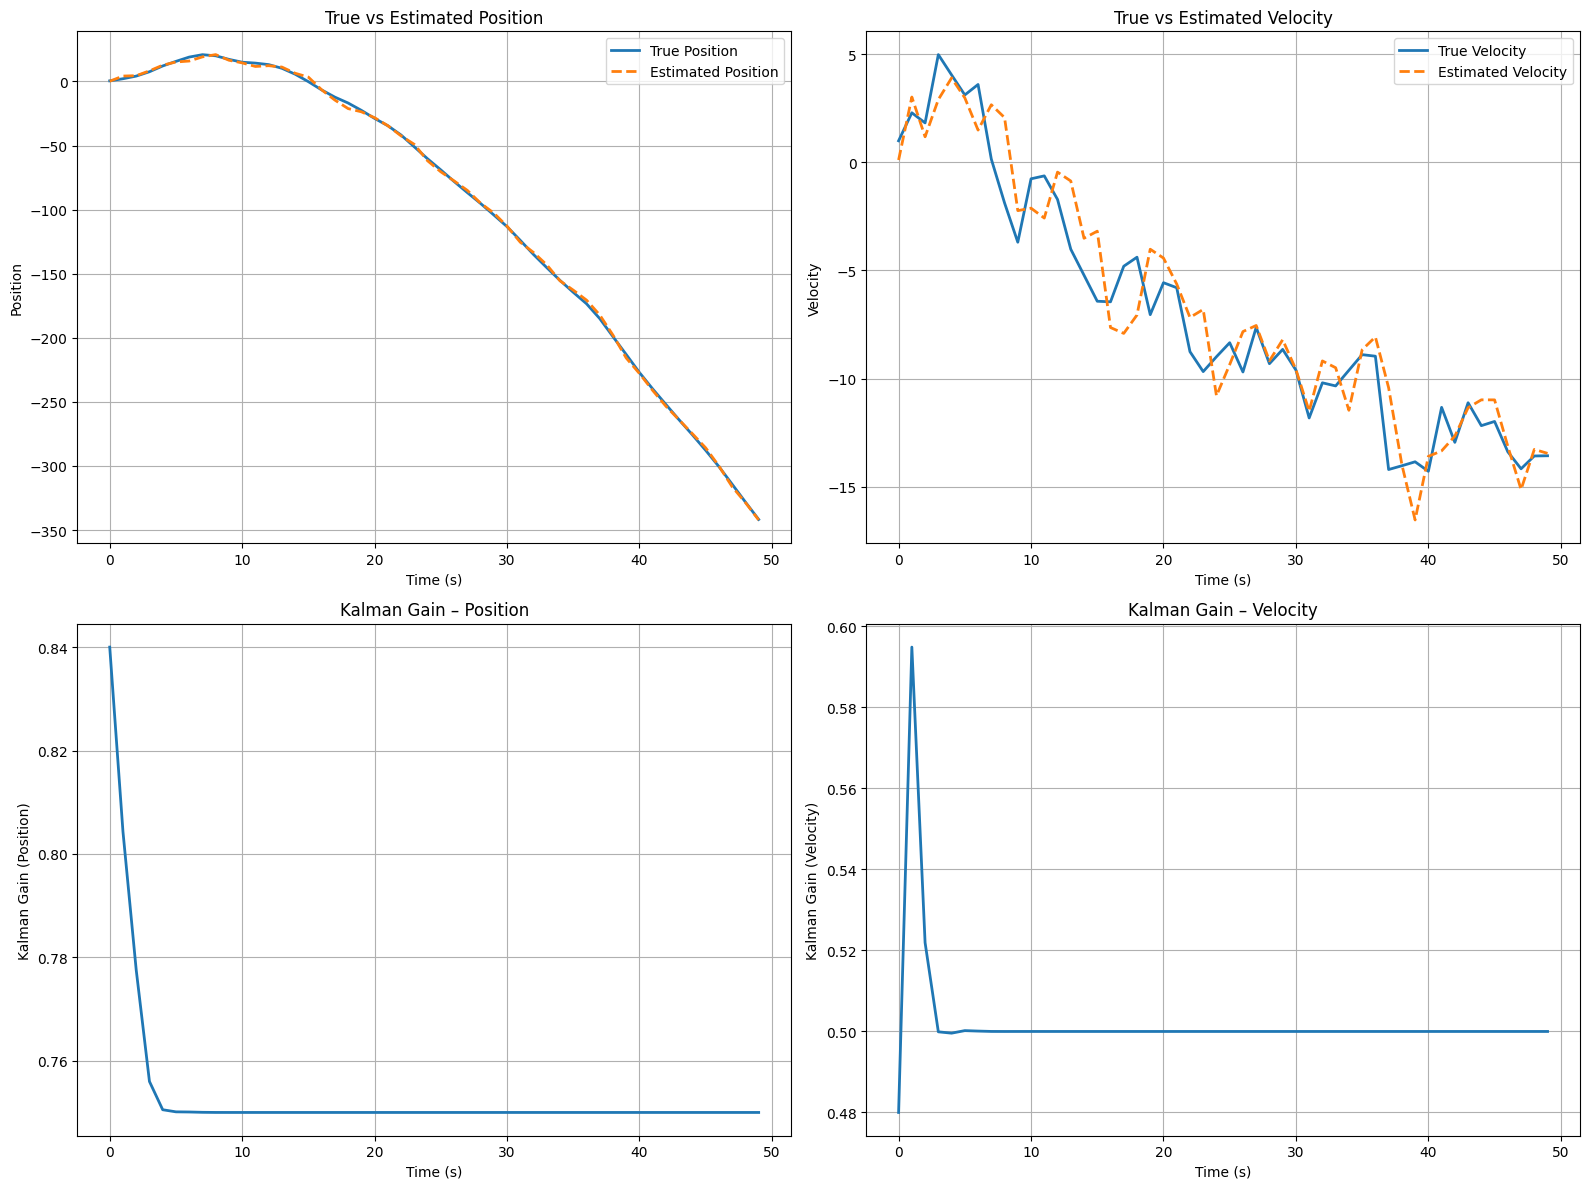

In [8]:
time = np.arange(n_steps) * dt

plt.figure(figsize=(16, 12))

# ------------------------------------------------
# True vs Estimated POSITION
# ------------------------------------------------
plt.subplot(2, 2, 1)
plt.plot(time, true_positions, label="True Position", linewidth=2)
plt.plot(time, np.array(estimates_x).flatten(),
         label="Estimated Position", linestyle="--", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Position")
plt.title("True vs Estimated Position")
plt.legend()
plt.grid(True)

# ------------------------------------------------
# True vs Estimated VELOCITY
# ------------------------------------------------
plt.subplot(2, 2, 2)
plt.plot(time, true_velocities, label="True Velocity", linewidth=2)
plt.plot(time, np.array(estimates_v).flatten(),
         label="Estimated Velocity", linestyle="--", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Velocity")
plt.title("True vs Estimated Velocity")
plt.legend()
plt.grid(True)

# ------------------------------------------------
# Kalman Gain for POSITION
# ------------------------------------------------
plt.subplot(2, 2, 3)
plt.plot(time, np.array(k_gain_x).flatten(), linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Kalman Gain (Position)")
plt.title("Kalman Gain – Position")
plt.grid(True)

# ------------------------------------------------
# Kalman Gain for VELOCITY
# ------------------------------------------------
plt.subplot(2, 2, 4)
plt.plot(time, np.array(k_gain_v).flatten(), linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Kalman Gain (Velocity)")
plt.title("Kalman Gain – Velocity")
plt.grid(True)

plt.tight_layout()
plt.show()


# Kalman Filter Matrices (1D Position & Velocity)

**State vector**
$$
\mathbf{x}_k =
\begin{bmatrix}
p_k \\
v_k
\end{bmatrix}
$$

**Initial estimate covariance**
$$
\mathbf{P}_0 =
\begin{bmatrix}
10 & 0 \\
0 & 10
\end{bmatrix}
$$

**State transition matrix**
$$
\mathbf{F} =
\begin{bmatrix}
1 & \Delta t \\
0 & 1
\end{bmatrix}
$$

**Measurement matrix (position only)**
$$
\mathbf{H} =
\begin{bmatrix}
1 & 0
\end{bmatrix}
$$

**Process noise covariance (random acceleration)**
$$
\mathbf{Q} =
\sigma_a^2
\begin{bmatrix}
\frac{\Delta t^4}{4} & \frac{\Delta t^3}{2} \\
\frac{\Delta t^3}{2} & \Delta t^2
\end{bmatrix}
$$

**Measurement noise covariance**
$$
\mathbf{R} =
\begin{bmatrix}
\sigma_z^2
\end{bmatrix}
$$


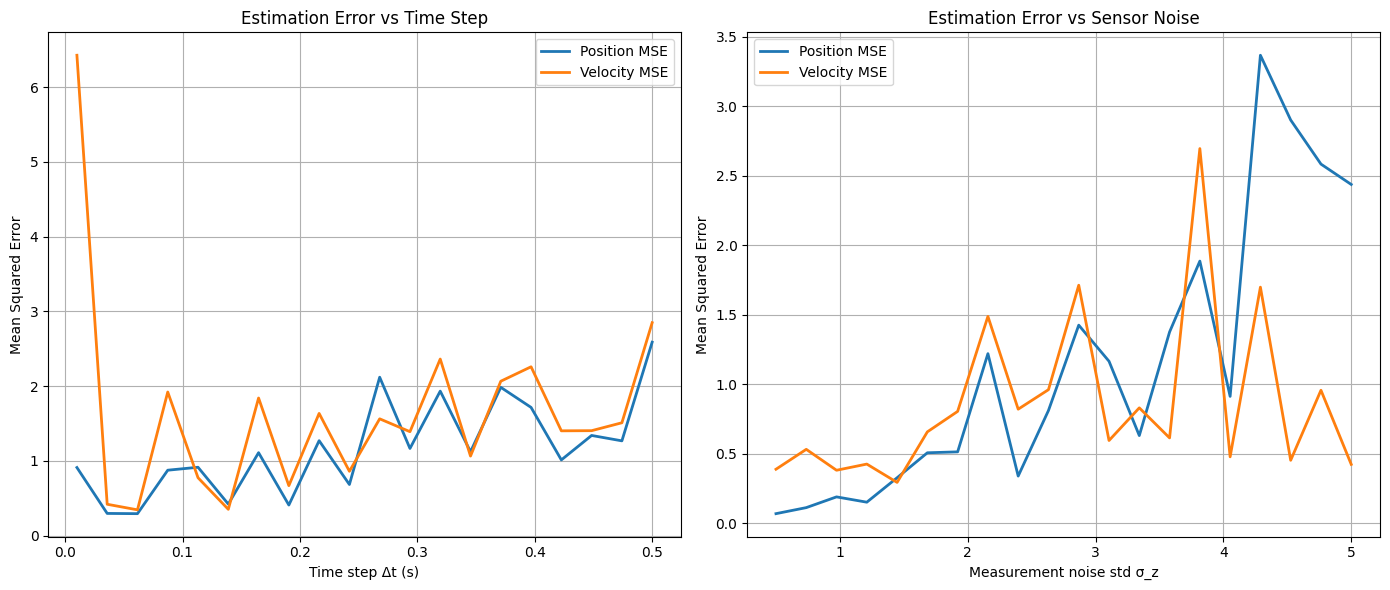

In [15]:
# Function to run Kalman filter and return MSE
np.random.seed(30)
def run_kalman(n_steps, dt, measurement_noise_std, acceleration_std=2.0):
    # -----------------------------
    # Generate true motion + measurements
    # ----------------------------
    true_positions = []
    true_velocities = []
    measurements = []

    position = 0.0
    velocity = 0.0
    for _ in range(n_steps):
        a = np.random.normal(0, acceleration_std)
        position += velocity * dt + 0.5 * a * dt**2
        velocity += a * dt
        true_positions.append(position)
        true_velocities.append(velocity)
        noisy_measurement = position + np.random.normal(0, measurement_noise_std)
        measurements.append(noisy_measurement)

    # -----------------------------
    # Kalman filter initialization
    # -----------------------------
    x_est = np.array([[0.0], [0.0]])
    P = np.array([[10.0, 0.0], [0.0, 10.0]])

    F = np.array([[1.0, dt], [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])
    Q = acceleration_std**2 * np.array([[dt**4/4, dt**3/2], [dt**3/2, dt**2]])
    R = np.array([[measurement_noise_std**2]])

    estimates_x = []
    estimates_v = []

    for z in measurements:
        # Prediction
        x_pred = F @ x_est
        P_pred = F @ P @ F.T + Q

        # Update
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        y = np.array([[z]]) - H @ x_pred
        x_est = x_pred + K @ y
        P = (np.eye(2) - K @ H) @ P_pred

        estimates_x.append(x_est[0,0])
        estimates_v.append(x_est[1,0])

    # Compute MSE
    mse_position = np.mean((np.array(true_positions) - np.array(estimates_x))**2)
    mse_velocity = np.mean((np.array(true_velocities) - np.array(estimates_v))**2)

    return mse_position, mse_velocity

# -----------------------------
# Sweep over different dt
# -----------------------------
n_steps = 50
dt_values = np.linspace(0.01, 0.5, 20)   # different time steps
mse_pos_dt = []
mse_vel_dt = []

for dt in dt_values:
    mse_p, mse_v = run_kalman(n_steps, dt, measurement_noise_std=2.0)
    mse_pos_dt.append(mse_p)
    mse_vel_dt.append(mse_v)

# -----------------------------
# Sweep over different measurement noise
# -----------------------------
sensor_noise_values = np.linspace(0.5, 5.0, 20)
mse_pos_R = []
mse_vel_R = []

for R_std in sensor_noise_values:
    mse_p, mse_v = run_kalman(n_steps, dt=0.1, measurement_noise_std=R_std)
    mse_pos_R.append(mse_p)
    mse_vel_R.append(mse_v)

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(14,6))

# Error vs dt
plt.subplot(1,2,1)
plt.plot(dt_values, mse_pos_dt, label="Position MSE", linewidth=2)
plt.plot(dt_values, mse_vel_dt, label="Velocity MSE", linewidth=2)
plt.xlabel("Time step Δt (s)")
plt.ylabel("Mean Squared Error")
plt.title("Estimation Error vs Time Step")
plt.legend()
plt.grid(True)

# Error vs Measurement Noise
plt.subplot(1,2,2)
plt.plot(sensor_noise_values, mse_pos_R, label="Position MSE", linewidth=2)
plt.plot(sensor_noise_values, mse_vel_R, label="Velocity MSE", linewidth=2)
plt.xlabel("Measurement noise std σ_z")
plt.ylabel("Mean Squared Error")
plt.title("Estimation Error vs Sensor Noise")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Upon altering the time step we directly modify the process uncertaininty, increasing by increasing the time step, and the measurement standard deviation is also sweeped from 0.5 to 5. The graphs indicate that there is no clear trend in the estimation error with Q and R. However a grid search can be performed on these values to find the set of values for which the estimation error is minimum.

Minimum estimation error: 0.268
Optimal time step Δt: 0.087 s
Optimal measurement std σ_z: 0.500


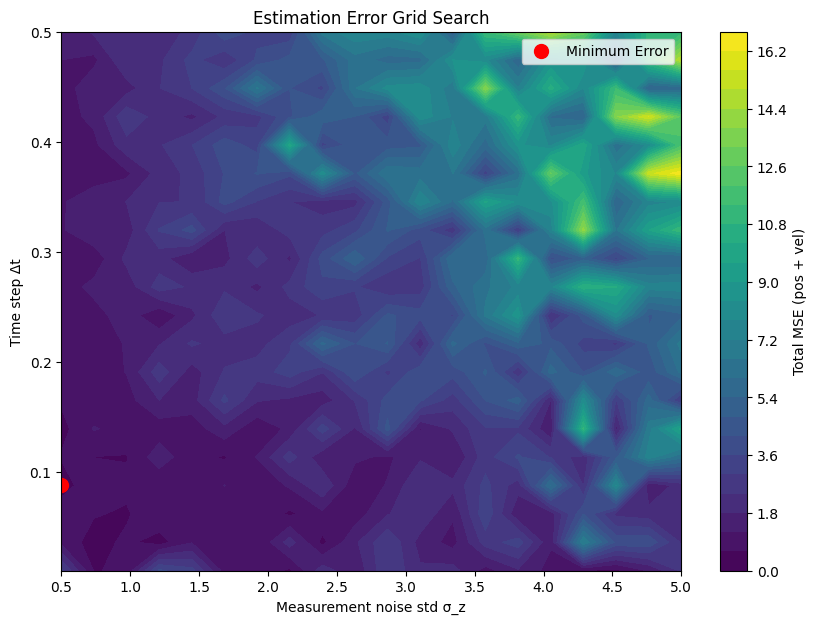

In [19]:
# -----------------------------
# Grid search parameters
# -----------------------------
np.random.seed(30)
dt_values = np.linspace(0.01, 0.5, 20)          # 20 time steps from 0.01s to 0.5s
sensor_noise_values = np.linspace(0.5, 5.0, 20) # 20 sensor noise levels

# Initialize MSE storage
mse_grid = np.zeros((len(dt_values), len(sensor_noise_values)))

# -----------------------------
# Run grid search
# -----------------------------
for i, dt in enumerate(dt_values):
    for j, R_std in enumerate(sensor_noise_values):
        mse_p, mse_v = run_kalman(n_steps=50, dt=dt, measurement_noise_std=R_std)
        mse_grid[i, j] = mse_p + mse_v  # combine position + velocity error

# -----------------------------
# Find minimum MSE
# -----------------------------
min_idx = np.unravel_index(np.argmin(mse_grid), mse_grid.shape)
best_dt = dt_values[min_idx[0]]
best_R = sensor_noise_values[min_idx[1]]
min_error = mse_grid[min_idx]

print(f"Minimum estimation error: {min_error:.3f}")
print(f"Optimal time step Δt: {best_dt:.3f} s")
print(f"Optimal measurement std σ_z: {best_R:.3f}")

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(10,7))
X, Y = np.meshgrid(sensor_noise_values, dt_values)
cp = plt.contourf(X, Y, mse_grid, levels=30, cmap='viridis')
plt.colorbar(cp, label='Total MSE (pos + vel)')
plt.scatter(best_R, best_dt, color='red', s=100, label='Minimum Error')
plt.xlabel('Measurement noise std σ_z')
plt.ylabel('Time step Δt')
plt.title('Estimation Error Grid Search')
plt.legend()
plt.show()
